## 2 Whisper Baseline

This notebook will get the baseline WER and CER scores for Romansh. For this the test set each idiom will be decoded with both OpenAI's Whisper.

In [1]:
import sys
from pathlib import Path

notebook_dir = Path.cwd()
whisper_dir = notebook_dir.parent
sys.path.append(str(whisper_dir))

import torch
import random
from transformers import WhisperProcessor, WhisperForConditionalGeneration

from whisper_asr import (
  transcribe_whisper, compute_wer, compute_cer, 
  plot_wer_violin,load_all_data, compute_idiom_results, 
  print_evaluation_results, normalize_romansh_text
)
from whisper_asr.utils import get_best_gpu

/local/scratch/matuor/Romansh-ASR/whisper/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


For now we will use the Whisper Medium, the constants can however be changed to use any other model.

In [2]:
WHISPER_MODEL = "medium"
BATCH_SIZE = 8

DEVICE = torch.device(f"cuda:{get_best_gpu()}" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Selected GPU 5 with 24088 MiB free memory
Using device: cuda:5


First we load all the test data and concatenate it to one dataframe.

In [3]:
df_test = load_all_data("test")
print(f"\nTotal test samples: {len(df_test)}")
df_test.sample(10)


Total test samples: 631


,audio_path,sentence,idiom
526,/local/scratch/matuor/Romansh-ASR/data/clean-d...,par me e sto bien ca sund ida ad amprender amp...,Sutsilvan
139,/local/scratch/matuor/Romansh-ASR/data/clean-d...,promis su promis gio promis vi promis no promi...,Puter
91,/local/scratch/matuor/Romansh-ASR/data/clean-d...,a saja una situaziun tuot calma cha tuots as t...,Puter
40,/local/scratch/matuor/Romansh-ASR/data/clean-d...,la vischnanca da bregaglia e vinavant pronta d...,RG
332,/local/scratch/matuor/Romansh-ASR/data/clean-d...,chegl capeta darar,Surmiran
506,/local/scratch/matuor/Romansh-ASR/data/clean-d...,la vardad divina an nossa creta cristifidevla ...,Sutsilvan
211,/local/scratch/matuor/Romansh-ASR/data/clean-d...,sofia e martin vinzens da luven lentschatta di...,Sursilvan
254,/local/scratch/matuor/Romansh-ASR/data/clean-d...,nus entschavin cun in giubileum dapi exact 10 ...,Sursilvan
379,/local/scratch/matuor/Romansh-ASR/data/clean-d...,per furtegna i dat er anc belezzas internas tg...,Surmiran
412,/local/scratch/matuor/Romansh-ASR/data/clean-d...,ehm ea stuez eir oder te stost eir,Surmiran


Then we can start transcribing with Whisper.

In [5]:
print("Loading Whisper model...")
processor = WhisperProcessor.from_pretrained(f"openai/whisper-{WHISPER_MODEL}")
model = WhisperForConditionalGeneration.from_pretrained(f"openai/whisper-{WHISPER_MODEL}")

print("Transcribing with Whisper...")
whisper_transcriptions = transcribe_whisper(
    model=model,
    processor=processor,
    audio_paths=df_test["audio_path"].tolist(),
    batch_size=BATCH_SIZE,
    device=DEVICE
)

df_test['transcriptions'] = whisper_transcriptions
print("Whisper transcription complete.")

Loading Whisper model...


Loading weights: 100%|██████████| 947/947 [00:00<00:00, 7220.56it/s]


Transcribing with Whisper...


Transcribing (Whisper): 100%|██████████| 79/79 [03:12<00:00,  2.44s/it]

Whisper transcription complete.


Before evaluating we normalize the sentences transcribed by Whisper. Since Whisper is not trained on Romansh it is not surprising that the baseline scores are poor.

In [6]:
df_test['transcriptions'] = df_test['transcriptions'].apply(normalize_romansh_text)
references = df_test['sentence']
transcriptions = df_test['transcriptions']
idioms = df_test['idiom']

summary_df, overall_wer, overall_cer, valid_pairs = compute_idiom_results(references, transcriptions, idioms)
print_evaluation_results(summary_df, overall_wer, overall_cer, len(df_test['audio_path']), len(valid_pairs))


OVERALL RESULTS
Total test samples: 631
Valid pairs: 631/631

Word Error Rate (WER): 0.9797 (97.97%)
Character Error Rate (CER): 0.5540 (55.40%)

PER IDIOM RESULTS

RG
  Samples: 81
  WER: 0.8923 (89.23%)
  CER: 0.5037 (50.37%)

PUTER
  Samples: 114
  WER: 0.9491 (94.91%)
  CER: 0.5230 (52.30%)

SURSILVAN
  Samples: 94
  WER: 0.9808 (98.08%)
  CER: 0.5478 (54.78%)

SURMIRAN
  Samples: 151
  WER: 1.0469 (104.69%)
  CER: 0.5601 (56.01%)

SUTSILVAN
  Samples: 94
  WER: 1.0668 (106.68%)
  CER: 0.6761 (67.61%)

VALLADER
  Samples: 97
  WER: 0.9312 (93.12%)
  CER: 0.5117 (51.17%)

SUMMARY TABLE
    idiom  samples      wer      cer
       RG       81 0.892344 0.503687
    Puter      114 0.949126 0.522975
Sursilvan       94 0.980826 0.547799
 Surmiran      151 1.046939 0.560136
Sutsilvan       94 1.066826 0.676138
 Vallader       97 0.931177 0.511684


/local/scratch/matuor/Romansh-ASR/whisper/whisper_asr/analysis.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/local/scratch/matuor/Romansh-ASR/whisper/whisper_asr/analysis.py:57: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


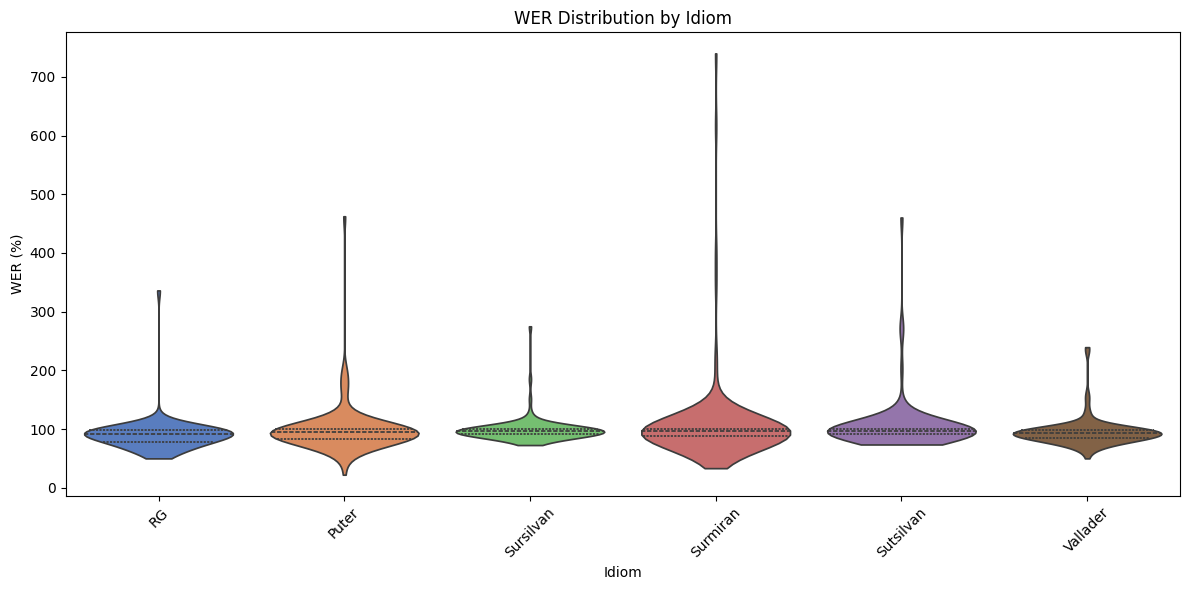

In [7]:
plot_wer_violin(references, transcriptions, idioms)

From the example transcriptions it becomes clear that Whisper is not trained on Romansh so it will just automatically detect a wrong language and then transcribe for that language.

In [ ]:
sample_indices = random.sample(range(len(valid_pairs)), min(5, len(valid_pairs)))

for i, idx in enumerate(sample_indices):
    print(f"--- Sample {i} ---")
    print(f"Idiom: {idioms[idx]}")
    print(f"Reference: {references[idx]}")
    print(f"Hypothesis: {transcriptions[idx]}")
    sample_wer, sample_cer = compute_wer(references[idx], transcriptions[idx]), compute_cer(references[idx], transcriptions[idx])
    print(f"Sample WER: {sample_wer:.4f}, Sample CER: {sample_cer:.4f}")
    print("-" * 40)

--- Sample 0 ---
Idiom: Puter
Reference: chanv agricul sainza t h c vegn gia hoz implanto in svizra per fer pevel o vivandas scu per exaimpel grauns ed oli cultiver chanv agricul o chanv da drogas quelo nu saja our da laspet agricul gniaunchusche una granda differenza
Hypothesis: o chanf agricola sem tac vem ja hoje implantado em julia para fazer pevel ou vivandes como por exemplo gremio e deol cultivar chanf agricola ou chanf de drogas que nao tem nada a ver com o aspecto agricola nao e uma grande diferenca
Sample WER: 1.0488, Sample CER: 0.4053
----------------------------------------
--- Sample 1 ---
Idiom: Sursilvan
Reference: jeu enquerel igl apparat da lavar giu il velo aber eventual hai jeu en tschella scaffa el cheu vesan ins co co la laura laria maglia si il gummi quei ei stiflas fetg bunas fetg caras enteifer in onn ei quei dat quei dapart
Hypothesis: jum kujre laprate lavadje ol velu avre eventuel vaj ovanj qe la shqiafela ko veten sko laura larea malje sel gumi ko e shtifle